# 天坛公园分钟级客流/指度数据探索性分析
本小节聚焦分钟级数据 (`number` 字段) 的统计描述数据、正态性检验以及平稳性检验，为后续的域变换（如对数变换、Box-Cox、差分等）提供数学依据。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
try:
    from statsmodels.tsa.stattools import adfuller
except ImportError:
    adfuller = None
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

file_path = r'd:\data\time-llm-rework\Time-LLM\my_data_pure\data - 20221118 - 20251231 - 分钟数据-天坛公园.csv'
df = pd.read_csv(file_path)
df['时间戳'] = pd.to_datetime(df['时间戳'])
# 确保按时间排序
df = df.sort_values(by='时间戳').reset_index(drop=True)
cols = ['number']
df.head()

,时间戳,number,number_flag,交通状况,环境描述,原始文件名
0,2022-11-18 09:00:00,0.36,original,通畅,舒适，适合参观游览。,2022-11-18_09-00.json
1,2022-11-18 09:15:00,0.30,original,通畅,舒适，适合参观游览。,2022-11-18_09-15.json
2,2022-11-18 09:30:00,0.34,original,通畅,舒适，适合参观游览。,2022-11-18_09-30.json
3,2022-11-18 09:45:00,0.37,original,通畅,舒适，适合参观游览。,2022-11-18_09-45.json
4,2022-11-18 10:00:00,0.31,original,通畅,舒适，适合参观游览。,2022-11-18_10-00.json


## 1. 基础描述性统计与方差分析
提供均值、标准差、离散程度以及丰富的百分位数，用于发现数据的基本范围和极值问题。

In [2]:
desc_stats = df[cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T
desc_stats['方差(var)'] = df[cols].var()
desc_stats['变异系数(CV)'] = desc_stats['std'] / desc_stats['mean'] # 衡量数据的相对离散程度
desc_stats['极差'] = desc_stats['max'] - desc_stats['min']
desc_stats

,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max,方差(var),变异系数(CV),极差
number,54720.0,0.885711,0.789626,0.0,0.07,0.18,0.35,0.67,1.19,1.83,2.31,3.47,58.79,0.623509,0.891517,58.79


## 2. 数据分布形态检验 (偏度、峰度与正态性检验)
- **偏度 (Skewness)**：衡量分布不对称性。>0为右偏(长尾在右侧，需要log变换使呈正态)，<0为左偏。
- **峰度 (Kurtosis)**：衡量尖峰程度。常态分布峰度偏离为0，>0表示尖峰厚尾 (极值多变)。
- **D'Agostino's K-squared 检验**：因为样本量远大于5000，使用 `scipy.stats.normaltest` 代替 Shapiro-Wilk 检验。P-value < 0.05 即拒绝原假设，说明不服从正态分布。如果不服从正态分布，通常建议做 Log 或 Box-Cox 变换。

In [3]:
normality_results = []
for col in cols:
    data_clean = df[col].dropna()
    if len(data_clean) < 8: continue
    kurtosis = data_clean.kurt()
    skewness = data_clean.skew()
    # 使用 D'Agostino K-squared test，适应大规模样本的正态性检验
    stat, p = stats.normaltest(data_clean)
    normality_results.append({
        '特征 (Feature)': col,
        '偏度 (Skewness)': skewness,
        '峰度 (Kurtosis)': kurtosis,
        'NormalTest 统计量': stat,
        'NormalTest P-value': p,
        '服从正态分布?': '是' if p > 0.05 else '否 (拒绝原假设)'
    })
pd.DataFrame(normality_results)

,特征 (Feature),偏度 (Skewness),峰度 (Kurtosis),NormalTest 统计量,NormalTest P-value,服从正态分布?
0,number,9.205183,537.241035,86442.774599,0.0,否 (拒绝原假设)


## 3. 平稳性检验 (ADF Test)
对时间序列进行平稳性检验。P-value < 0.05 表示拒绝原假设，序列是**平稳的**。
- 若不平稳（p > 0.05），在投入训练之前大概率需要进行**一阶差分**或者去除趋势项以达到平稳。

In [4]:
adf_results = []
if adfuller is not None:
    for col in cols:
        data_clean = df[col].dropna()
        if len(data_clean) > 0:
            result = adfuller(data_clean)
            adf_results.append({
                '特征 (Feature)': col,
                'ADF 统计量': result[0],
                'P-value': result[1],
                '1% 临界值': result[4]['1%'],
                '5% 临界值': result[4]['5%'],
                '10% 临界值': result[4]['10%'],
                '是否平稳?': '是 (平稳序列)' if result[1] < 0.05 else '否 (需要差分等域变换)'
            })
    display(pd.DataFrame(adf_results))
else:
    print("未检测到 statsmodels 库，跳过平稳性检验。")

,特征 (Feature),ADF 统计量,P-value,1% 临界值,5% 临界值,10% 临界值,是否平稳?
0,number,-13.345519,5.805410e-25,-3.43047,-2.861593,-2.566798,是 (平稳序列)


## 4. 滚动波动率统计 (检查方差非齐性 / 异方差)
针对分钟级数据，假定每天 96 个时间点 (每15分钟一条数据)：
我们将计算 1天 (96) 以及 30天 (2880) 滚动标准差的最大与最小比值。如果不同时期的标准差相差极大，说明存在**异方差性**（方差随时间剧烈变化），需要**Log 变换或 Box-Cox 变换**来稳定方差。

In [5]:
var_hetero_results = []
for col in cols:
    roll_1d_std = df[col].rolling(96).std().dropna()    # 1天
    roll_30d_std = df[col].rolling(2880).std().dropna() # 30天
    
    var_hetero_results.append({
        '特征 (Feature)': col,
        '1天滚动标准差极差比 (Max/Min)': roll_1d_std.max() / (roll_1d_std.min() + 1e-6),
        '30天滚动标准差极差比 (Max/Min)': roll_30d_std.max() / (roll_30d_std.min() + 1e-6),
    })
    
vdf = pd.DataFrame(var_hetero_results)
display(vdf)

,特征 (Feature),1天滚动标准差极差比 (Max/Min),30天滚动标准差极差比 (Max/Min)
0,number,5.892613e+06,36.913974


## 5. 补充图表（辅助肉眼观察数据状态）
结合数值统计，直接查看分钟级密集数据的分布特征与时序走势。

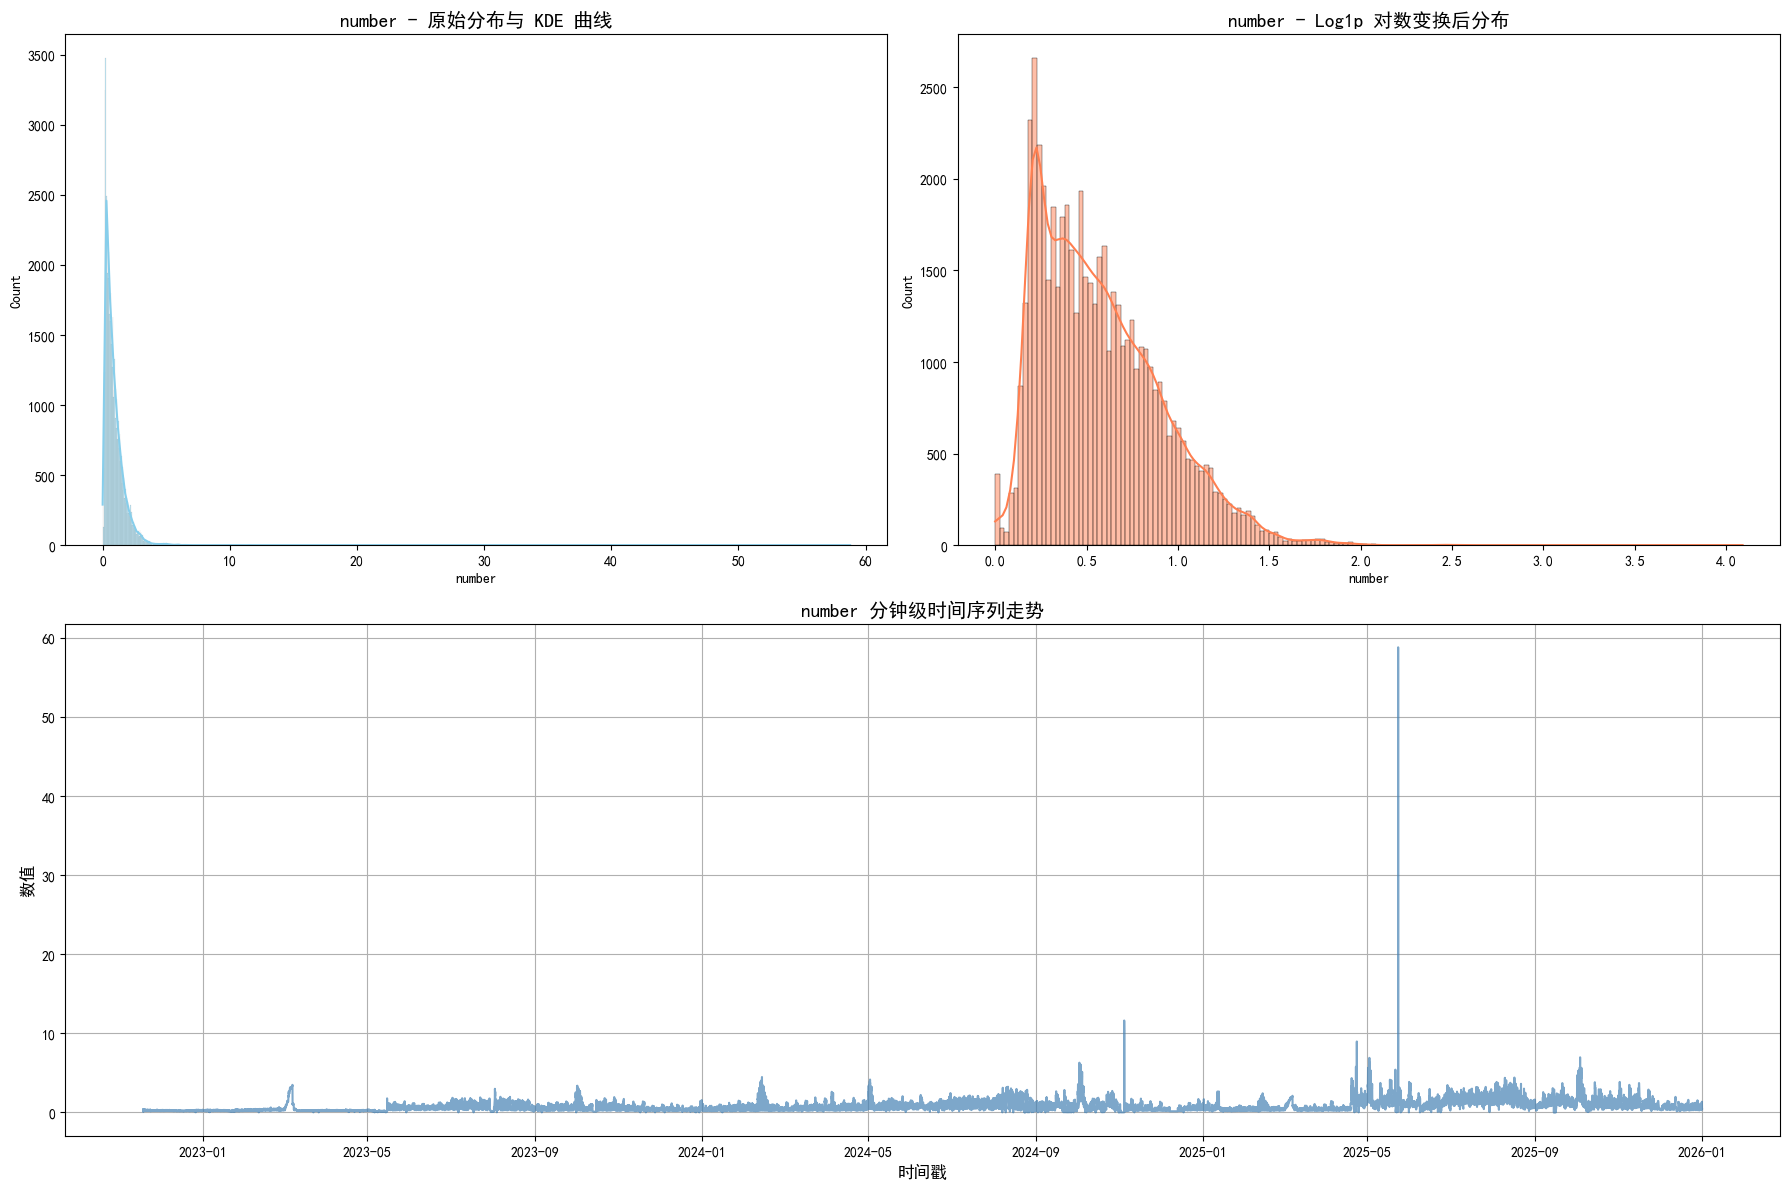

In [6]:
fig = plt.figure(figsize=(18, 12))
ax1 = fig.add_subplot(2, 2, 1)
sns.histplot(df['number'].dropna(), kde=True, ax=ax1, color='skyblue')
ax1.set_title('number - 原始分布与 KDE 曲线', fontsize=14)

ax2 = fig.add_subplot(2, 2, 2)
sns.histplot(np.log1p(df['number'].dropna()), kde=True, ax=ax2, color='coral')
ax2.set_title('number - Log1p 对数变换后分布', fontsize=14)

ax3 = fig.add_subplot(2, 1, 2)
ax3.plot(df['时间戳'], df['number'], alpha=0.7, color='steelblue')
ax3.set_title('number 分钟级时间序列走势', fontsize=14)
ax3.set_xlabel('时间戳', fontsize=12)
ax3.set_ylabel('数值', fontsize=12)
ax3.grid(True)

plt.tight_layout()
plt.show()

## 6. 天坛实地流量数据与百度指数双源对比分析
将天坛公园的高频钟级流量指标 (`number`) 按日聚合（取日均值），与对应日期的百度指数 `PC+移动指数` 开展联合分析。
通过双Y轴的趋势观察两大不同维度上的共振，并在下方求取皮尔逊与斯皮尔曼相关系数，判断“线上搜索趋势预热”与“实地流量爆发”是否存在统计意义层面的强联动。

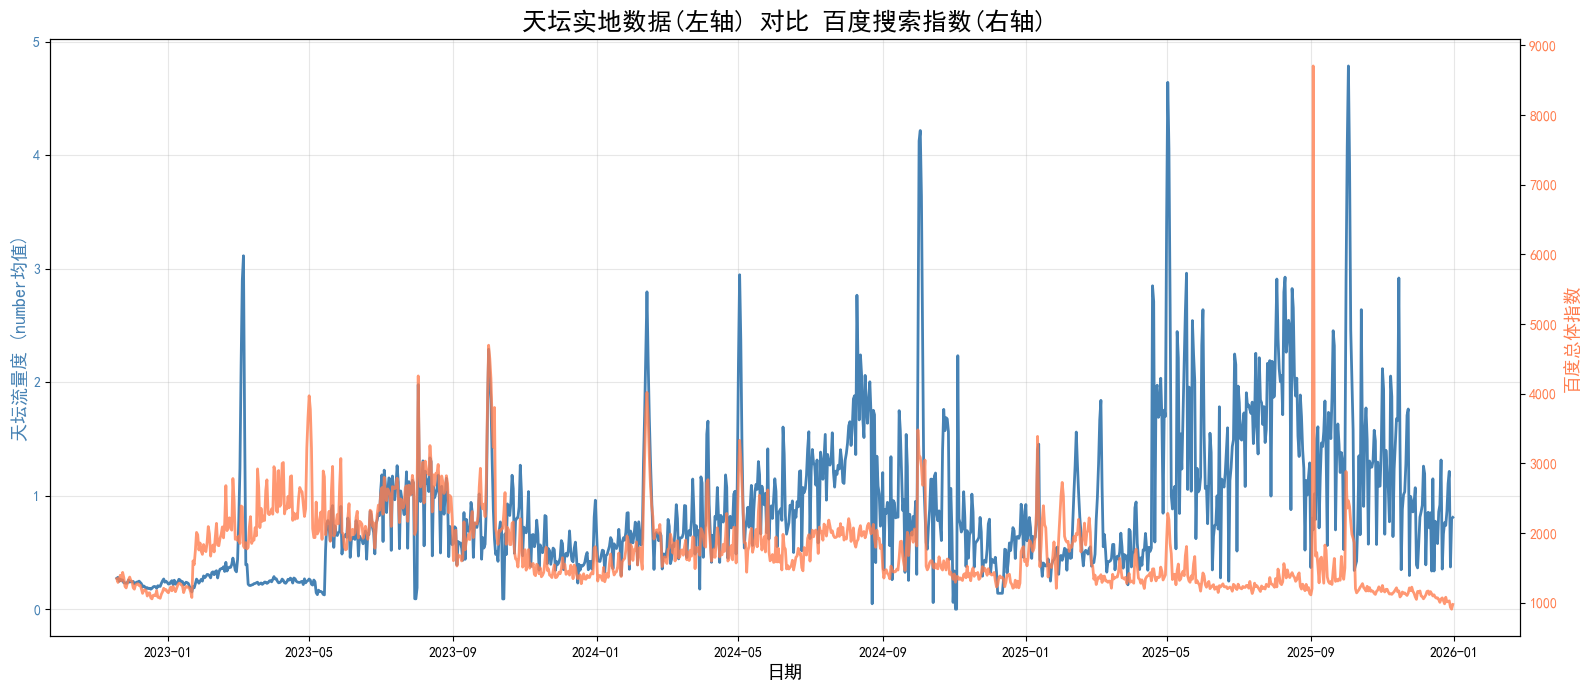

========== [相关性指标分析] ==========
【皮尔逊相关系数 (测定线性相关程度)】


,天坛实地指度均值,PC+移动指数
天坛实地指度均值,1.000000,0.095617
PC+移动指数,0.095617,1.000000



【斯皮尔曼级秩相关系数 (测定整体非线性单调趋势)】


,天坛实地指度均值,PC+移动指数
天坛实地指度均值,1.000000,0.039818
PC+移动指数,0.039818,1.000000


In [7]:
baidu_path = r'd:\data\time-llm-rework\Time-LLM\my_data_pure\百度指数_daily_merge_tiantan_20220601_20260131.csv'
df_baidu = pd.read_csv(baidu_path)
df_baidu['日期'] = pd.to_datetime(df_baidu['日期'])
df_baidu_daily = df_baidu[['日期', 'PC+移动指数']].set_index('日期')

# 1. 聚合天坛分钟级数据为日度级别（求均值或者求和均可，这里取当日日均流量负荷）
df_tiantan_daily = df.set_index('时间戳').resample('D')['number'].mean().reset_index()
df_tiantan_daily.columns = ['日期', '天坛实地指度均值']
df_tiantan_daily = df_tiantan_daily.set_index('日期')

# 2. 多源数据时间对齐与合并
df_merge = pd.merge(df_tiantan_daily, df_baidu_daily, left_index=True, right_index=True, how='inner')

# 3. 绘制双坐标轴趋势对比图
fig, ax1 = plt.subplots(figsize=(16, 7))

color1 = 'steelblue'
ax1.plot(df_merge.index, df_merge['天坛实地指度均值'], color=color1, linewidth=2, label='天坛实地流量 (日均)')
ax1.set_xlabel('日期', fontsize=13)
ax1.set_ylabel('天坛流量度 (number均值)', color=color1, fontsize=13, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_title('天坛实地数据(左轴) 对比 百度搜索指数(右轴)', fontsize=18, fontweight='bold')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()  # 共用 X 轴，右侧 Y 轴处理百度指数的大绝对值
color2 = 'coral'
ax2.plot(df_merge.index, df_merge['PC+移动指数'], color=color2, linewidth=2, alpha=0.8, label='百度搜索指数')
ax2.set_ylabel('百度总体指数', color=color2, fontsize=13, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color2)
fig.tight_layout()
plt.show()

# 4. 输出线性和单调相关的相关系数矩阵（皮尔逊和斯皮尔曼对比较好）
print("========== [相关性指标分析] ==========")
print("【皮尔逊相关系数 (测定线性相关程度)】")
display(df_merge.corr(method='pearson'))
print("\n【斯皮尔曼级秩相关系数 (测定整体非线性单调趋势)】")
display(df_merge.corr(method='spearman'))